In [22]:
import librosa
import soundfile as sf  # 用于保存音频文件 (pip install soundfile)

audio_path = "capture/audio_bgm.mp3"

y, sr = librosa.load(audio_path, sr=None)
duration = librosa.get_duration(y=y, sr=sr)

tempo_array, beat_frames = librosa.beat.beat_track(y=y, sr=sr)
beat_times = librosa.frames_to_time(beat_frames, sr=sr)
beat_clicks = librosa.clicks(times=beat_times, sr=sr, length=len(y), click_freq=880)

onset_frames = librosa.onset.onset_detect(y=y, sr=sr, backtrack=True)
onset_times = librosa.frames_to_time(onset_frames, sr=sr)
onset_clicks = librosa.clicks(times=onset_times, sr=sr, length=len(y), click_freq=880)

y_with_clicks = y + beat_clicks + onset_clicks
sf.write("check_beats_output.wav", y_with_clicks, sr)

array([ 0.08126984,  0.39473923,  0.69659864,  0.8707483 ,  0.99845805,
        1.31192744,  1.6370068 ,  1.96208617,  2.12462585,  2.2523356 ,
        2.57741497,  2.89088435,  3.21596372,  3.36689342,  3.52943311,
        3.66875283,  3.83129252,  4.1447619 ,  4.30730159,  4.45823129,
        4.609161  ,  5.07356009,  5.38702948,  5.71210884,  6.02557823,
        6.18811791,  6.32743764,  6.6060771 ,  6.95437642,  7.1169161 ,
        7.2678458 ,  9.75238095, 10.06585034, 10.24      , 10.37931973,
       10.54185941, 10.98303855, 11.48226757, 11.93505669, 12.10920635,
       12.24852608, 12.58521542, 13.03800454, 13.20054422, 13.52562358,
       13.96680272, 14.43120181, 14.60535147, 14.77950113, 15.37160998,
       15.62702948, 15.84761905, 16.03337868, 16.32362812, 16.61387755,
       16.88090703, 17.1014966 , 17.57750567, 17.74004535, 18.18122449,
       18.51791383, 18.79655329, 19.13324263, 19.37705215, 19.6092517 ,
       19.69052154])

In [ ]:
import librosa

# 1. 加载音频并提取节拍点
y, sr = librosa.load(audio_path, sr=None)
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr)
beat_times = librosa.frames_to_time(beat_frames, sr=sr)

# 2. 生成与节拍点对齐的“点击声”
# length=len(y) 保证点击声轨道的长度和原音频完全一致
clicks = librosa.clicks(times=beat_times, sr=sr, length=len(y), click_freq=880)

# 3. 将点击声叠加到原音频上
y_with_clicks = y + clicks

# 4. 导出为新的 WAV 文件文件进行试听
sf.write("check_beats_output.wav", y_with_clicks, sr)
print("节拍对比音频已生成：check_beats_output.wav，请戴上耳机听听是否踩准。")

节拍对比音频已生成：check_beats_output.wav，请戴上耳机听听是否踩准。


In [17]:
import librosa
import soundfile as sf  # 用于保存音频文件 (pip install soundfile)

# 1. 加载音频并提取节拍点
y, sr = librosa.load(audio_path, sr=None)
onset_frames = librosa.onset.onset_detect(y=y, sr=sr, backtrack=True)
onset_times = librosa.frames_to_time(onset_frames, sr=sr)

# 2. 生成与节拍点对齐的“点击声”
# length=len(y) 保证点击声轨道的长度和原音频完全一致
clicks = librosa.clicks(times=onset_times, sr=sr, length=len(y), click_freq=880)

# 3. 将点击声叠加到原音频上
y_with_clicks = y + clicks

# 4. 导出为新的 WAV 文件文件进行试听
sf.write("check_beats_output.wav", y_with_clicks, sr)
print("节拍对比音频已生成：check_beats_output.wav，请戴上耳机听听是否踩准。")

节拍对比音频已生成：check_beats_output.wav，请戴上耳机听听是否踩准。


In [10]:
import librosa
import soundfile as sf  # 用于保存音频文件 (pip install soundfile)

# 1. 加载音频并提取节拍点
audio_path = "./capture/audio_bgm_(Other)_htdemucs_ft.mp3"
y, sr = librosa.load(audio_path, sr=None)
onset_frames = librosa.onset.onset_detect(y=y, sr=sr, backtrack=True)
onset_times = librosa.frames_to_time(onset_frames, sr=sr)

# 2. 生成与节拍点对齐的“点击声”
# length=len(y) 保证点击声轨道的长度和原音频完全一致
clicks = librosa.clicks(times=onset_times, sr=sr, length=len(y), click_freq=880)

# 3. 将点击声叠加到原音频上
y_with_clicks = y + clicks

# 4. 导出为新的 WAV 文件文件进行试听
sf.write("check_beats_output.wav", y_with_clicks, sr)
print("节拍对比音频已生成：check_beats_output.wav，请戴上耳机听听是否踩准。")

节拍对比音频已生成：check_beats_output.wav，请戴上耳机听听是否踩准。


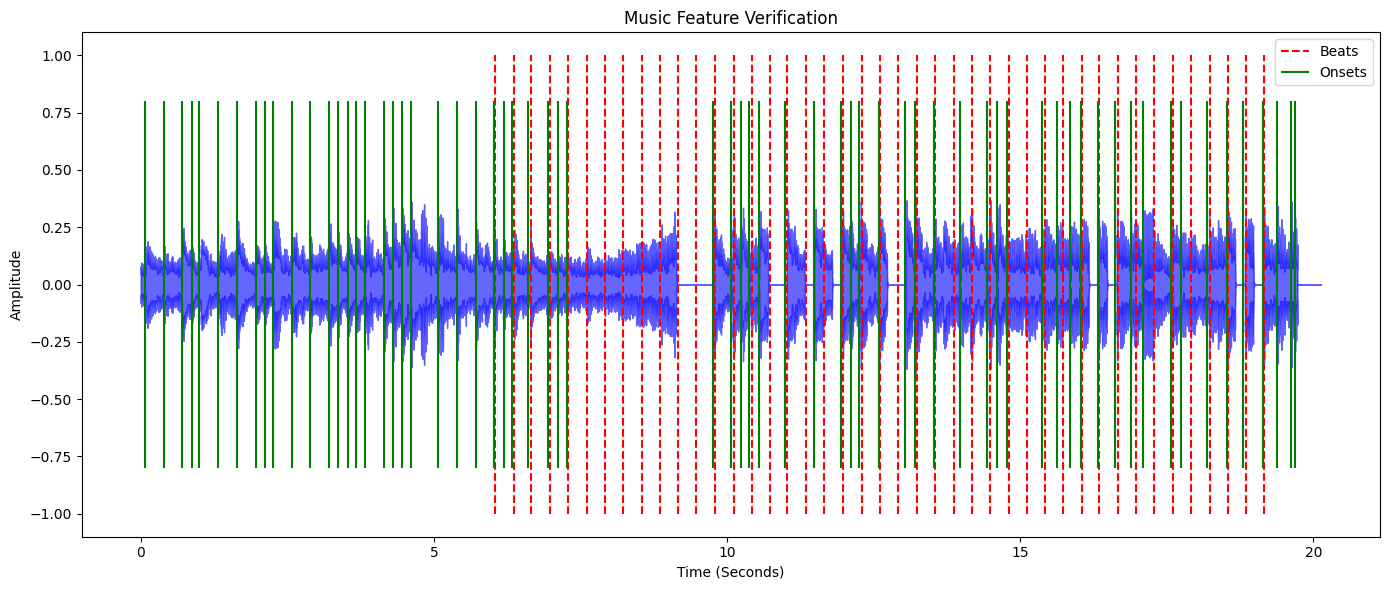

In [24]:
import librosa.display
import matplotlib.pyplot as plt

# 提取重拍起始点
onset_frames = librosa.onset.onset_detect(y=y, sr=sr, backtrack=True)
onset_times = librosa.frames_to_time(onset_frames, sr=sr)

plt.figure(figsize=(14, 6))

# 绘制原音频波形图
librosa.display.waveshow(y, sr=sr, alpha=0.6, color="blue")

# 绘制节拍点（红色虚线）
plt.vlines(beat_times, ymin=-1, ymax=1, color="r", linestyle="--", label="Beats")

# 绘制重拍起始点（绿色实线，只显示前20个防止画面太密）
plt.vlines(
    onset_times,
    ymin=-0.8,
    ymax=0.8,
    color="g",
    linestyle="-",
    label="Onsets",
)

plt.title("Music Feature Verification")
plt.xlabel("Time (Seconds)")
plt.ylabel("Amplitude")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [11]:
import librosa
import soundfile as sf  # 用于保存音频文件 (pip install soundfile)

# 1. 加载音频并提取节拍点
audio_path = "./capture/audio_bgm_(Drums)_htdemucs_ft.mp3"
y, sr = librosa.load(audio_path, sr=None)
onset_frames = librosa.onset.onset_detect(y=y, sr=sr, backtrack=True)
onset_times = librosa.frames_to_time(onset_frames, sr=sr)

# 2. 生成与节拍点对齐的“点击声”
# length=len(y) 保证点击声轨道的长度和原音频完全一致
clicks = librosa.clicks(times=onset_times, sr=sr, length=len(y), click_freq=880)

# 3. 将点击声叠加到原音频上
y_with_clicks = y + clicks

# 4. 导出为新的 WAV 文件文件进行试听
sf.write("check_beats_output.wav", y_with_clicks, sr)
print("节拍对比音频已生成：check_beats_output.wav，请戴上耳机听听是否踩准。")

节拍对比音频已生成：check_beats_output.wav，请戴上耳机听听是否踩准。


In [12]:
import librosa
import soundfile as sf  # 用于保存音频文件 (pip install soundfile)


def get_onset_clicks(audio_path):
    y, sr = librosa.load(audio_path, sr=None)
    onset_frames = librosa.onset.onset_detect(y=y, sr=sr, backtrack=True)
    onset_times = librosa.frames_to_time(onset_frames, sr=sr)
    clicks = librosa.clicks(times=onset_times, sr=sr, length=len(y), click_freq=880)
    return y, clicks, sr


y1, clicks1, sr = get_onset_clicks("./capture/audio_bgm_(Drums)_htdemucs_ft.mp3")
y2, clicks2, sr = get_onset_clicks("./capture/audio_bgm_(Other)_htdemucs_ft.mp3")
y_with_clicks = y1 + clicks2 + clicks1 + y2

# 4. 导出为新的 WAV 文件文件进行试听
sf.write("check_beats_output.wav", y_with_clicks, sr)
print("节拍对比音频已生成：check_beats_output.wav，请戴上耳机听听是否踩准。")

节拍对比音频已生成：check_beats_output.wav，请戴上耳机听听是否踩准。


In [27]:
import librosa
import numpy as np


def extract_music_features(audio_path):
    print(f"正在加载音频文件: {audio_path} ...")

    # 1. 加载音频 (sr=None 保证读取音频原始采样率，不进行强制重采样)
    y, sr = librosa.load(audio_path, sr=None)
    duration = librosa.get_duration(y=y, sr=sr)
    print(f"加载成功! 采样率: {sr} Hz, 总时长: {duration:.2f} 秒\n")

    features = {}

    # =====================================================================
    # 2. 节奏与时间特征（核心：用于视频卡点）
    # =====================================================================
    print(" [1/3] 正在提取节奏与时间特征...")

    # 提取全局 BPM 和节拍对应的帧索引 (beat_frames)
    # 注：在 librosa 新版本中，tempo 返回的可能是一个数组，我们取其平均值或第一个元素
    tempo_array, beat_frames = librosa.beat.beat_track(y=y, sr=sr)
    bpm = float(np.mean(tempo_array))

    # 将节拍的“帧索引”转换为绝对“时间戳（秒）”
    beat_times = librosa.frames_to_time(beat_frames, sr=sr)

    features["bpm"] = bpm
    features["beat_times"] = beat_times

    # 起始点检测 (Onset Detection) —— 寻找声音能量爆发的点（通常是鼓点或新音符的开始）
    # backtrack=True 可以让对齐更精准，更适合做卡点
    onset_frames = librosa.onset.onset_detect(y=y, sr=sr, backtrack=True)
    onset_times = librosa.frames_to_time(onset_frames, sr=sr)

    # 计算起始点强度曲线（用于分辨哪个重拍更强）
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    # 获取每个检测到的重拍点上的能量强度
    onset_strengths = onset_env[onset_frames]

    features["onset_times"] = onset_times
    features["onset_strengths"] = onset_strengths

    # =====================================================================
    # 3. 能量与音色特征（用于视觉特效联动、风格识别）
    # =====================================================================
    print(" [2/3] 正在提取能量与音色特征...")

    # 短时能量 / 均方根能量 (RMS) —— 反映音乐的实时响度和力量感
    rms = librosa.feature.rms(y=y)[0]
    features["rms"] = rms

    # 谱质心 (Spectral Centroid) —— 反映声音的明亮程度/高低频倾向
    spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    features["spectral_centroids"] = spectral_centroids

    # 梅尔频率倒谱系数 (MFCCs) —— 包含丰富的音色信息，常用于区分乐器和曲风
    # n_mfcc=13 是标准配置，矩阵维度为 (13, 帧数)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    features["mfcc"] = mfcc

    # =====================================================================
    # 4. 和声与调性特征（用于旋律二次创作）
    # =====================================================================
    print(" [3/3] 正在提取和声与调性特征...")

    # 色度图特征 (Chroma STFT) —— 将频率压缩到音乐的 12 个半音（C, C#, D...）上
    # 矩阵维度为 (12, 帧数)，能完美反映当前的和弦和调性走向
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features["chroma"] = chroma

    print("\n所有特征提取完毕！")
    return features, sr


audio_path = "capture/audio_bgm.mp3"
try:
    feats, sample_rate = extract_music_features(audio_path)

    # 打印部分提取结果进行验证
    print("\n--- 提取结果摘要 ---")
    print(f"1. 预估 BPM: {feats['bpm']:.2f}")
    print(
        f"2. 节拍点数量: {len(feats['beat_times'])} 个 (前5个点: {feats['beat_times'][:5]})"
    )
    print(
        f"3. 重拍/起始点数量: {len(feats['onset_times'])} 个 (前5个点: {feats['onset_times'][:5]})"
    )
    print(f"4. RMS 能量序列长度: {len(feats['rms'])} 帧")
    print(f"5. 谱质心序列长度: {len(feats['spectral_centroids'])} 帧")
    print(f"6. MFCC 矩阵维度: {feats['mfcc'].shape}")
    print(f"7. 色度特征(Chroma) 维度: {feats['chroma'].shape}")

except FileNotFoundError:
    print(f"\n[错误] 未找到文件 '{audio_path}'，请修改代码中的音频路径进行测试。")

正在加载音频文件: capture/audio_bgm.mp3 ...
加载成功! 采样率: 44100 Hz, 总时长: 20.13 秒

 [1/3] 正在提取节奏与时间特征...
 [2/3] 正在提取能量与音色特征...
 [3/3] 正在提取和声与调性特征...

所有特征提取完毕！

--- 提取结果摘要 ---
1. 预估 BPM: 191.41
2. 节拍点数量: 43 个 (前5个点: [6.04879819 6.36226757 6.66412698 6.97759637 7.29106576])
3. 重拍/起始点数量: 66 个 (前5个点: [0.08126984 0.39473923 0.69659864 0.8707483  0.99845805])
4. RMS 能量序列长度: 1735 帧
5. 谱质心序列长度: 1735 帧
6. MFCC 矩阵维度: (13, 1735)
7. 色度特征(Chroma) 维度: (12, 1735)


In [44]:
import librosa
import soundfile as sf


def merge_adjacent_beats(times, threshold=0.07):
    """
    邻近点融合算法（贪心聚类）
    :param times: 已经排序好的时间戳一维数组 (秒)
    :param threshold: 融合阈值 (秒)。默认 0.07 秒(70毫秒)。
                      如果两个点挨得比这个近，就认为它们是同一个音乐事件。
    :return: 融合去重后的黄金卡点时间戳
    """
    if len(times) == 0:
        return np.array([])

    merged_times = []
    # 建立一个临时的簇（Cluster）来存放靠得很近的点
    current_cluster = [times[0]]

    for t in times[1:]:
        # 如果当前点距离上一个点小于阈值，说明它们靠得极近，并入同一个簇
        if t - current_cluster[-1] < threshold:
            current_cluster.append(t)
        else:
            # 如果拉开了距离，说明进入了下一个节拍。
            # 计算当前簇的平均值，作为这个节拍的最终代表点
            merged_times.append(np.mean(current_cluster))
            # 开启一个新的簇
            current_cluster = [t]

    # 不要漏掉最后一个簇
    merged_times.append(np.mean(current_cluster))

    return np.array(merged_times)


def generate_golden_cut_points(
    audio_path, output_wav="golden_beats_check.wav", threshold=0.07
):
    print("Step 1: 正在加载音频并进行时频分离...")
    y, sr = librosa.load(audio_path, sr=None)

    print("Step 2: 正在提取全局标准节拍 (Beat Tracking)...")
    tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr)
    beat_times = librosa.frames_to_time(beat_frames, sr=sr)

    print("Step 3: 正在通过 Superflux 提取局部物理重拍 (Onset Detection)...")
    # 采用针对密集重拍优化过的自适应参数
    onset_frames = librosa.onset.onset_detect(y=y, sr=sr, backtrack=True)
    onset_times = librosa.frames_to_time(onset_frames, sr=sr)

    print(
        f"-> 原始数据统计：标准 Beat 共 {len(beat_times)} 个，物理 Onset 共 {len(onset_times)} 个。"
    )

    print("Step 4: 合流并进行时间轴排序...")
    # 将两组时间戳合并并重新升序排列
    combined_times = np.sort(np.concatenate([beat_times, onset_times]))

    print(f"Step 5: 启动去重算法（融合阈值: {threshold * 1000:.0f} ms）...")
    final_cut_times = merge_adjacent_beats(combined_times, threshold=threshold)
    print(f"✨ 融合去重成功！最终输出黄金卡点点数: {len(final_cut_times)} 个。")

    return final_cut_times


try:
    # threshold=0.07 (70ms) 通常是人耳和视觉在视频剪辑中判定“在同一个时间点”的极限公差
    gold_beats = generate_golden_cut_points(audio_path, threshold=0.1)
    clicks = librosa.clicks(times=gold_beats, sr=sr, length=len(y), click_freq=1000)
    y_with_clicks = y + clicks
    sf.write("final_golden_beats_check.wav", y_with_clicks, sr)
    # 打印部分结果看看
    print("\n最终输出的 beat_times (前15个点):")
    print(np.round(gold_beats[:15], 3))

except FileNotFoundError:
    print(f"未找到文件 {audio_path}")

Step 1: 正在加载音频并进行时频分离...
Step 2: 正在提取全局标准节拍 (Beat Tracking)...
Step 3: 正在通过 Superflux 提取局部物理重拍 (Onset Detection)...
-> 原始数据统计：标准 Beat 共 43 个，物理 Onset 共 66 个。
Step 4: 合流并进行时间轴排序...
Step 5: 启动去重算法（融合阈值: 100 ms）...
✨ 融合去重成功！最终输出黄金卡点点数: 82 个。

最终输出的 beat_times (前15个点):
[0.081 0.395 0.697 0.871 0.998 1.312 1.637 1.962 2.125 2.252 2.577 2.891
 3.216 3.367 3.529]
